In [1]:
source("preparar_dataframes.r")
source("src/sstvars_wrapper.r")


[1] "Se creó df_trimestral_crudo"
[1] "Se creó df_Arg"
[1] "Se creó df_ERPT_Arg1"
[1] "Se creó df_ERPT_Arg"


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: ‘sstvars’


The following object is masked from ‘package:tsDyn’:

    GIRF




## Ejemplo TVAR (threshold)

In [2]:
res <- run_threshold_tvar(
  data = df_ERPT_Arg,
  endog = c("Pmaíz_USA","E","ipc","pbird"),
  periodicity = 'trimestral', # 'trimestral' o 'anual'
  feature_lag = 2,
  n_regimes = 2,
  cumulative = TRUE,
  thr_var = 'ipc', # 'ipc'
  thr_lag = 1,
  shock_var = 'E', # 'E'
  response_vars = c('ipc'), # c("Pmaíz_USA","ipc","pbird")
  run_tests = TRUE, # ejecuta e imprime tests: portmonteau, descomposición histórica y GEFVD
  irf_horizons = NULL, # Max períodos hacia los que mirar adelante en IRF (NULL = 2 años, default = 2 años)
  irf_shocks = 1, # Shocks unitarios irf (default 1)
  diagnostic_plots = TRUE, # Imprimir plots de diagnostico? TRUE o FALSE (default FALSE)
  nrounds = 250, # Cantidad de iteraciones - para ver resultados poco confiables rápido poner bajito, si no dejar en 500 o incluso 1000 (default 500)
  load_presaved = TRUE
)
#Correr los siguientes en celdas aparte
#print_girf(res) #Si querés ver los resultados de GIRF, descomentame
#print_irf(res) #Si querés ver los resultados de IRF lineal, descomentame
# OJO: A ESTA HAY QUE PASARLE LOS MISMOS PARÁMETROS QUE A RUN_VLSTAR!!
#run_tests_sstvar(res, response_vars = c('ipc'), cumulative = TRUE, irf_horizons = NULL, irf_shocks = 1, nrounds = 1)

Warning message in gzfile(file, "rb"):
“cannot open compressed file 'models/threshold_tvar_2_2_250_971bb005e48ae8a0608d9d26f578adc8.rds', probable reason 'No such file or directory'”


ERROR: Error in gzfile(file, "rb"): cannot open the connection


## Ejemplo VLSTAR (logistic)

Using 2 cores for 1 estimations rounds...

PHASE 1: Estimating all the parameters with a genetic algorithm...



Results from the genetic algorithm:

The lowest loglik:  1288.344

The largest loglik: 1288.344

PHASE 2: Estimating all the parameters with a variable metric algorithm...

Results from the variable metric algorithm:

The lowest loglik:  1288.344

The largest loglik: 1288.344

Filtering inappropriate estimates...

No 'appropriate'estimates found! Check that all the variables are scaled to vary in similar magninutes, also not very small or large magnitudes.

Consider running more estimation rounds or study the obtained estimates one-by-one with the function alt_stvar.

Calculating approximate standard errors...

Warning message in warn_eigens(ret, allow_unstab = allow_unstab):
“Regimes 1 and 2 have near-singular error term covariance matrices! Consider building a model from the next-largest local maximum with the function 'alt_stvar' by adjusting its argument 'which_largest' (or use the function 'filter_estimates').”
Finished!




========= Unstructured fitted model ==========


Calculating approximate standard errors...



========= Structured fitted model (heteroskedasticity) ==========
Saving trained models to models/ folder
 >>> Portmanteau
Portmanteau test (autocorr): 
 test stat = 401.3, df = 288, p-value = 1.109e-05

 >>> Historical Decomposition
The contributions of the shocks to the fluctuations of Pmaíz_USA: 
    Shock 1 Shock 2 Shock 3 Shock 4
3    -0.008   0.046  -0.014  -0.052
4     0.036   0.036   0.061  -0.005
5     0.014  -0.048   0.005   0.052
6     0.003  -0.009  -0.021   0.030
7    -0.018   0.021  -0.014   0.005
8    -0.004  -0.005  -0.011   0.024
9    -0.002   0.032  -0.047   0.037
10   -0.041   0.100  -0.060   0.007
11   -0.084  -0.033  -0.031  -0.001
12   -0.011  -0.045   0.017   0.008
13   -0.017  -0.024   0.056  -0.013
14   -0.012  -0.008   0.031  -0.007
15   -0.053  -0.037   0.002  -0.005
16    0.004   0.038  -0.004   0.005
17   -0.009   0.060  -0.051   0.021
18    0.025  -0.061   0.051   0.013
19   -0.033  -0.094   0.041   0.000
20   -0.027  -0.002   0.018  -0.007
21   -0.023   0

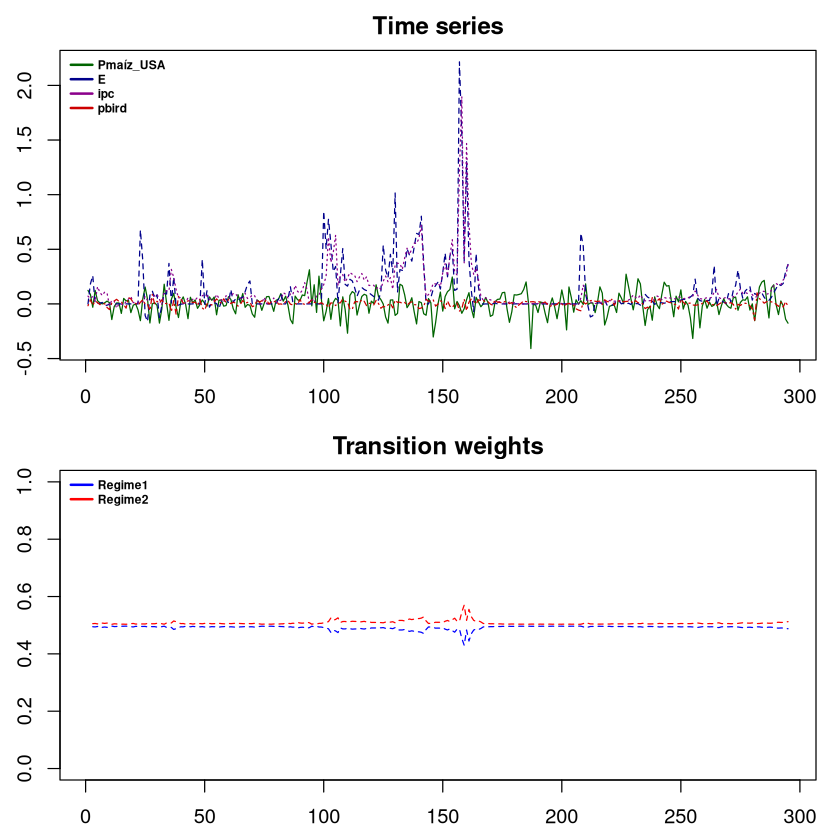

+++++++++ RÉGIMEN  1 +++++++++
 >>> GIRF


Using 2 cores to estimate 250 GIRFs for 1 structural shocks, each based on 1 Monte Carlo repetitions.

Estimating GIRFs for structural shock 2...

Finished!



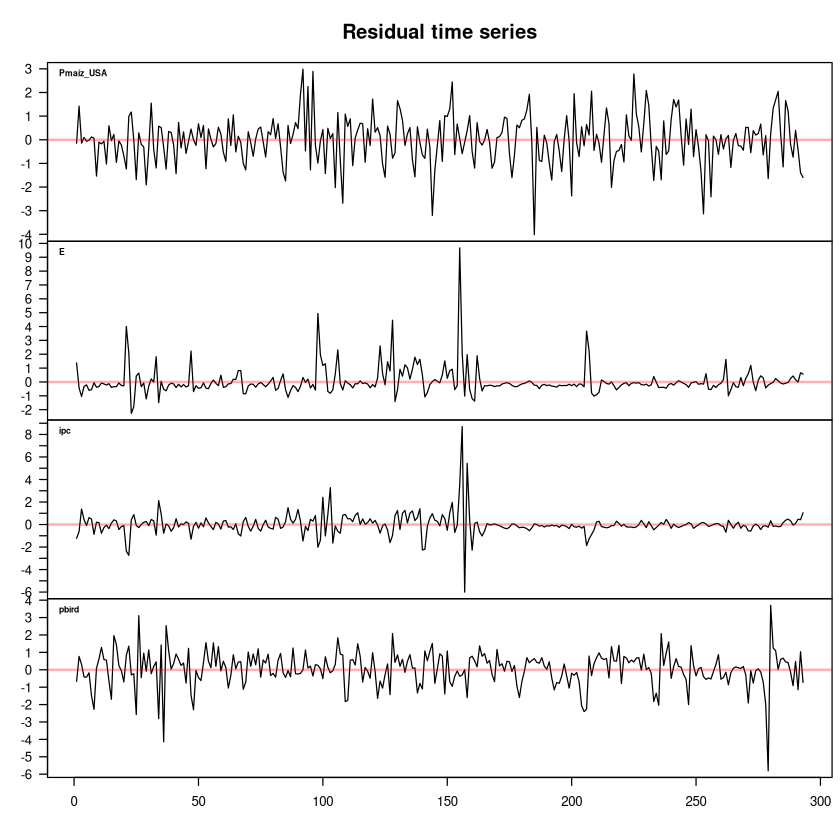

 >>> Linear IRF (1 shock)

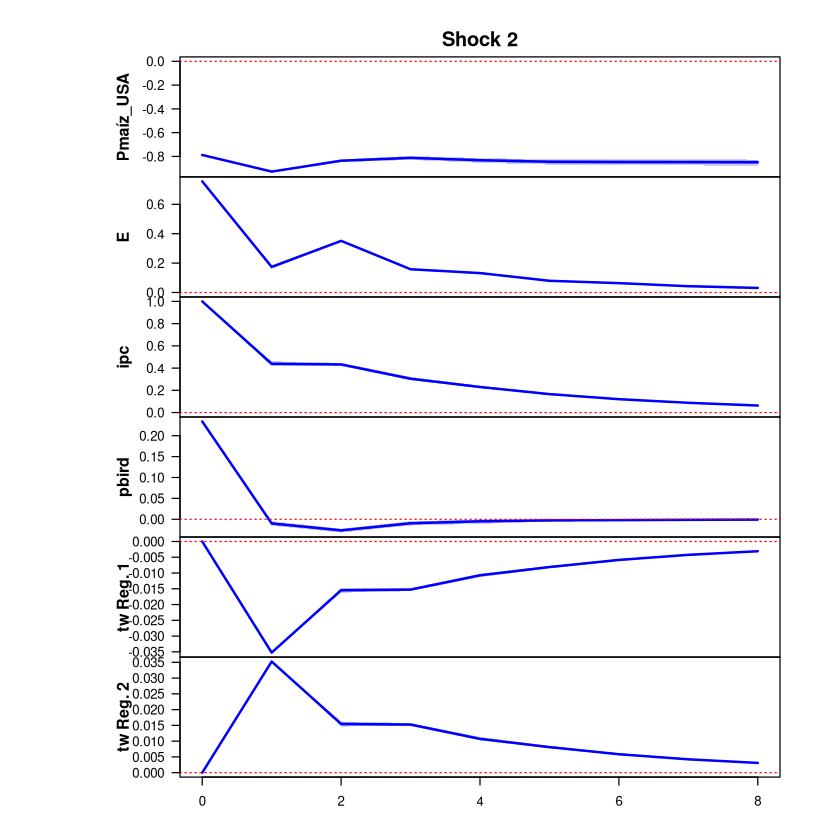

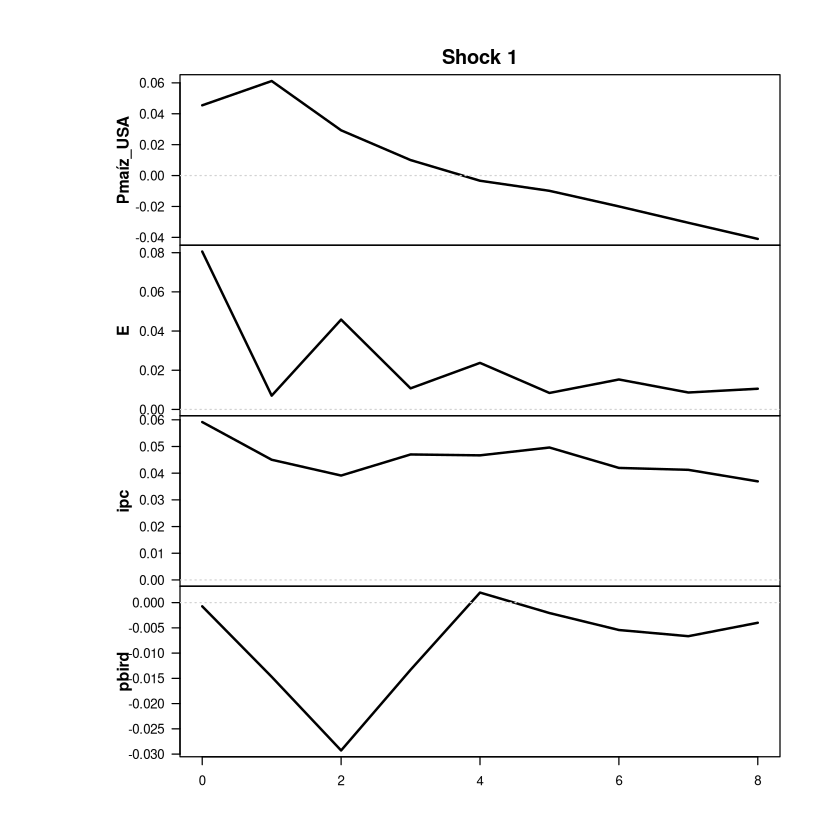

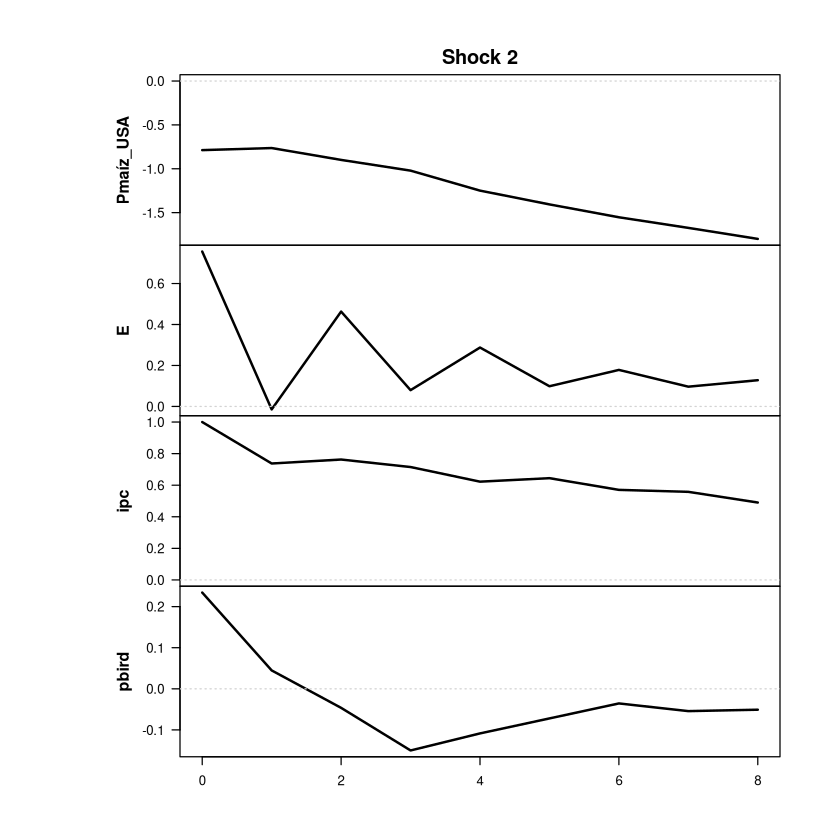

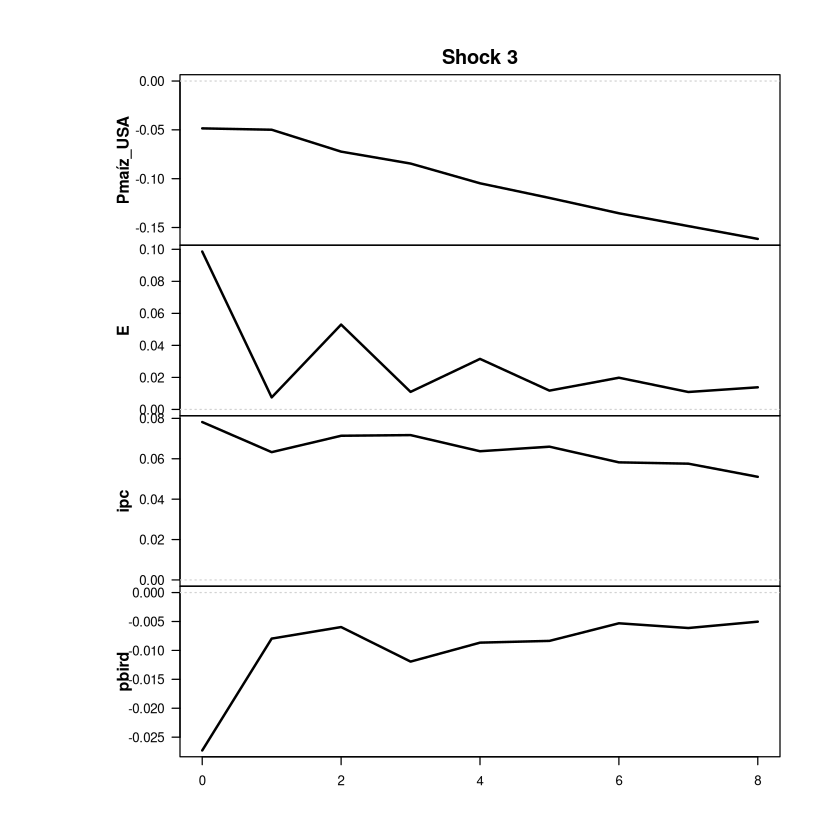

+++++++++ RÉGIMEN  2 +++++++++
 >>> GIRF


Using 2 cores to estimate 250 GIRFs for 1 structural shocks, each based on 1 Monte Carlo repetitions.

Estimating GIRFs for structural shock 2...

Finished!



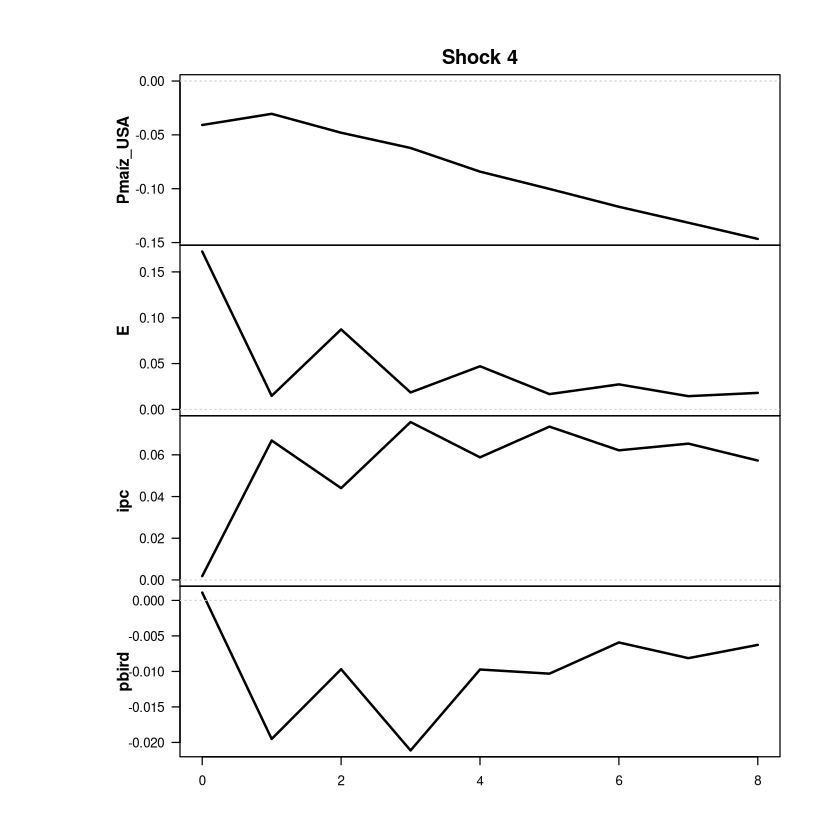

 >>> Linear IRF (1 shock)

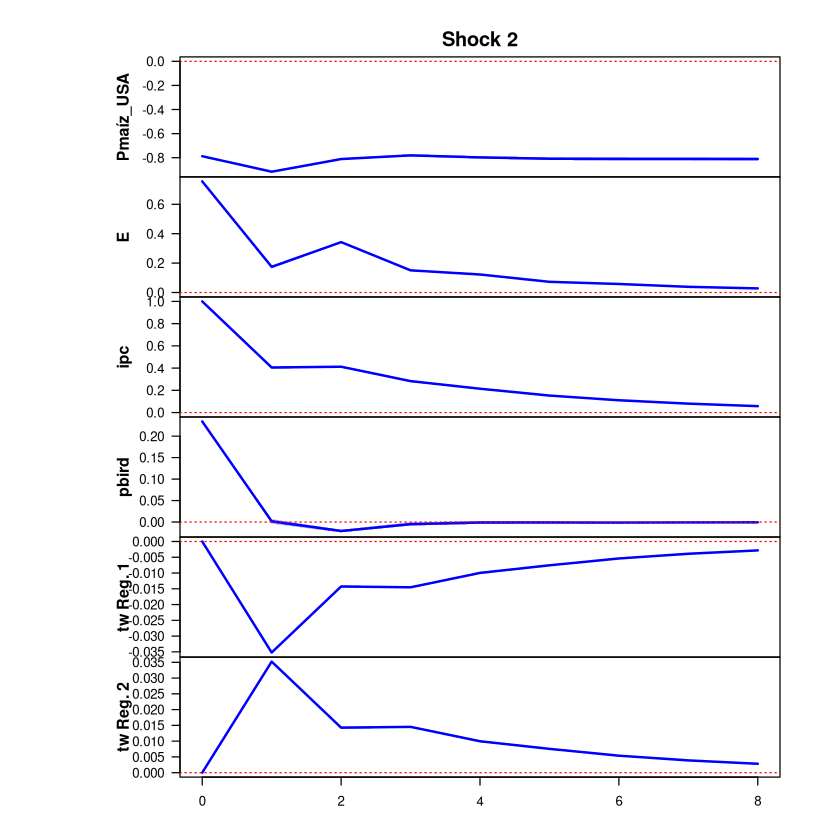

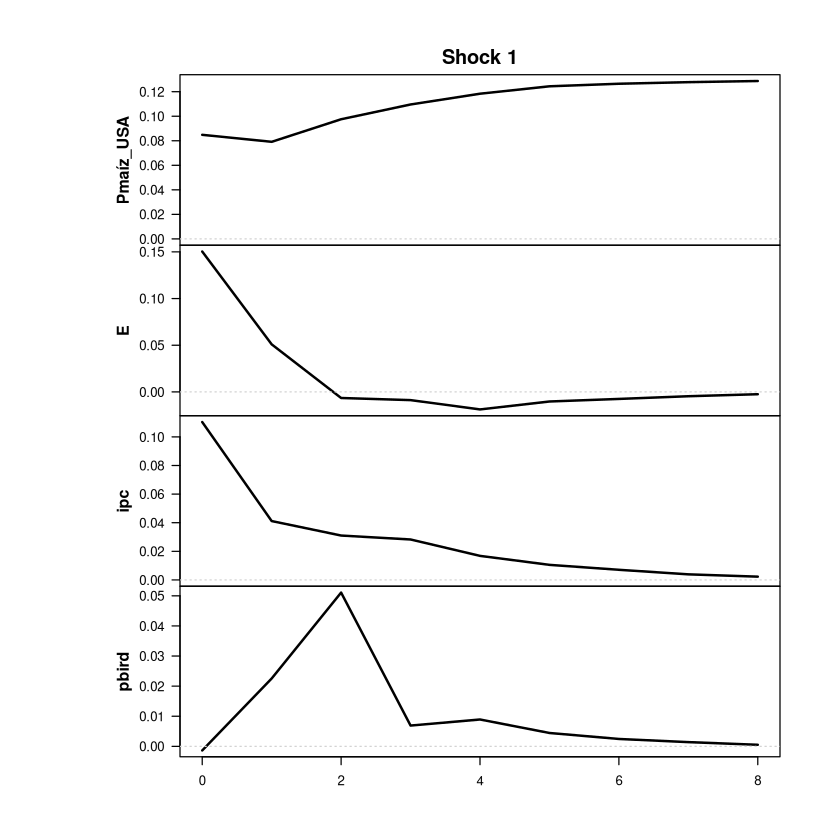

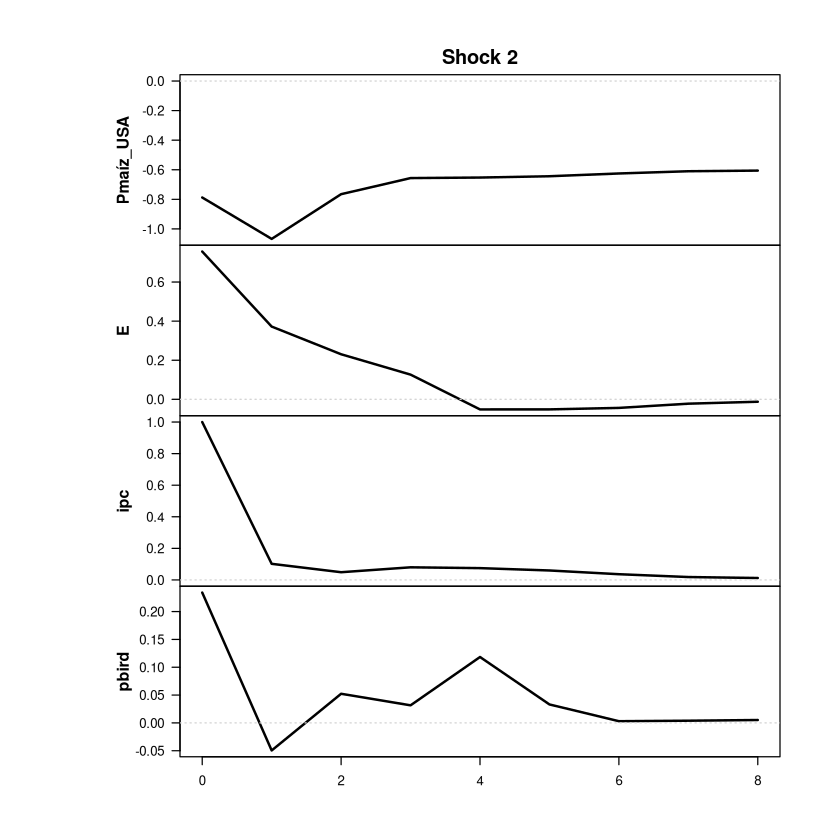

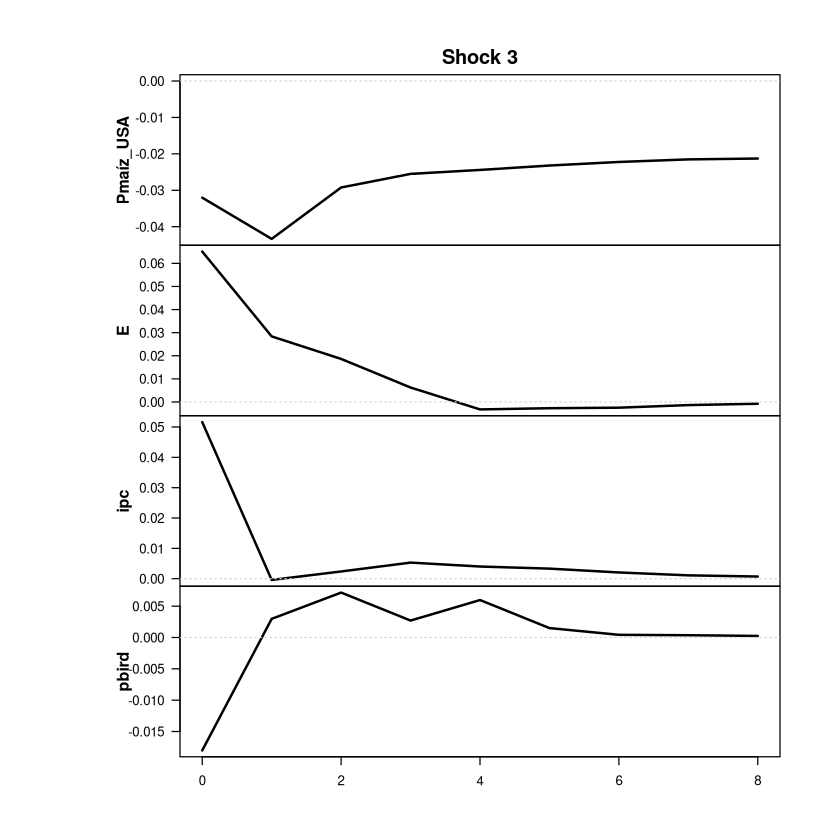

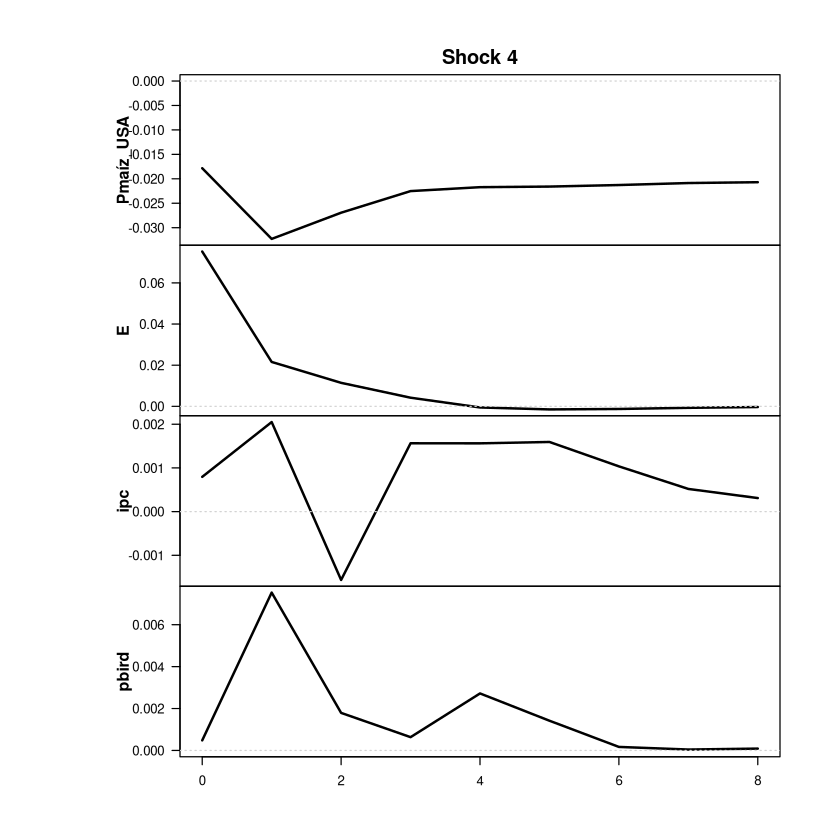

In [ ]:
res <- run_vlstar (
  data = df_ERPT_Arg,
  endog = c("Pmaíz_USA","E","ipc","pbird"),
  periodicity = 'trimestral', # 'trimestral' o 'anual'
  feature_lag = 2,
  n_regimes = 2,
  cumulative = TRUE,
  thr_var = 'ipc', # 'ipc'
  thr_lag = 1,
  shock_var = 'E', # 'E'
  response_vars = c('ipc'), # c("Pmaíz_USA","ipc","pbird")
  run_tests = FALSE, # ejecuta e imprime tests: portmonteau, descomposición histórica y GEFVD
  irf_horizons = NULL, # Max períodos hacia los que mirar adelante en IRF (NULL = 2 años, default = 2 años)
  irf_shocks = 1, # Shocks unitarios irf (default 1)
  diagnostic_plots = TRUE, # Imprimir plots de diagnostico? TRUE o FALSE (default FALSE)
  nrounds = 500, # Cantidad de iteraciones - para ver resultados poco confiables rápido poner bajito, si no dejar en 500 o incluso 1000 (default 500)
  load_presaved = FALSE
)
#Correr los siguientes en celdas aparte
#print_girf(res) #Si querés ver los resultados de GIRF, descomentame
#print_irf(res) #Si querés ver los resultados de IRF lineal, descomentame
# OJO: A ESTA HAY QUE PASARLE LOS MISMOS PARÁMETROS QUE A RUN_VLSTAR!!
#run_tests_sstvar(res, response_vars = c('ipc'), cumulative = TRUE, irf_horizons = NULL, irf_shocks = 1, nrounds = 1)